In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nTransaction amount stats:")
print(df['Amount'].describe())

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%

Missing values: 0

Transaction amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [2]:
conn = sqlite3.connect('../data/processed/fraud_warehouse.db')

df.to_sql('transactions', conn, if_exists='replace', index=False)

df['hour'] = (df['Time'] // 3600).astype(int)

hourly_stats = df.groupby('hour').agg(
    total_transactions=('Class', 'count'),
    fraud_count=('Class', 'sum'),
    total_amount=('Amount', 'sum'),
    avg_amount=('Amount', 'mean'),
    max_amount=('Amount', 'max')
).reset_index()
hourly_stats['fraud_rate'] = hourly_stats['fraud_count'] / hourly_stats['total_transactions']
hourly_stats.to_sql('hourly_stats', conn, if_exists='replace', index=False)

print("✅ Database created with tables: transactions, hourly_stats")
print(f"Transactions table: {pd.read_sql('SELECT COUNT(*) as n FROM transactions', conn).values[0][0]:,} rows")
print(f"Hourly stats table: {pd.read_sql('SELECT COUNT(*) as n FROM hourly_stats', conn).values[0][0]:,} rows")

✅ Database created with tables: transactions, hourly_stats
Transactions table: 284,807 rows
Hourly stats table: 48 rows


In [3]:
# Query 1: Rolling fraud rate using window function
query1 = """
SELECT 
    hour,
    total_transactions,
    fraud_count,
    fraud_rate,
    AVG(fraud_rate) OVER (
        ORDER BY hour 
        ROWS BETWEEN 5 PRECEDING AND CURRENT ROW
    ) as rolling_6hr_fraud_rate,
    SUM(total_amount) OVER (ORDER BY hour) as cumulative_amount
FROM hourly_stats
ORDER BY hour
"""
rolling_stats = pd.read_sql(query1, conn)
print("Rolling fraud rate analysis:")
print(rolling_stats.head(10).to_string())

# Query 2: High risk hours — 2 standard deviations above mean
mean_fraud = rolling_stats['fraud_rate'].mean()
std_fraud = rolling_stats['fraud_rate'].std()

high_risk = rolling_stats[rolling_stats['fraud_rate'] > mean_fraud + 2 * std_fraud]
print(f"\nMean fraud rate: {mean_fraud:.4%}")
print(f"Std deviation:  {std_fraud:.4%}")
print(f"High risk threshold: {(mean_fraud + 2*std_fraud):.4%}")
print(f"\nHigh risk hours identified: {len(high_risk)}")
print(high_risk[['hour', 'total_transactions', 'fraud_count', 'fraud_rate']].to_string())

Rolling fraud rate analysis:
   hour  total_transactions  fraud_count  fraud_rate  rolling_6hr_fraud_rate  cumulative_amount
0     0                3963            2    0.000505                0.000505          257101.87
1     1                2217            2    0.000902                0.000703          403207.56
2     2                1576           21    0.013325                0.004911          512026.73
3     3                1821           13    0.007139                0.005468          606333.57
4     4                1082            6    0.005545                0.005483          686174.19
5     5                1681           11    0.006544                0.005660          763300.11
6     6                1831            3    0.001638                0.005849          905703.60
7     7                3368           23    0.006829                0.006837         1179009.58
8     8                5179            5    0.000965                0.004777         1648785.34
9     9    

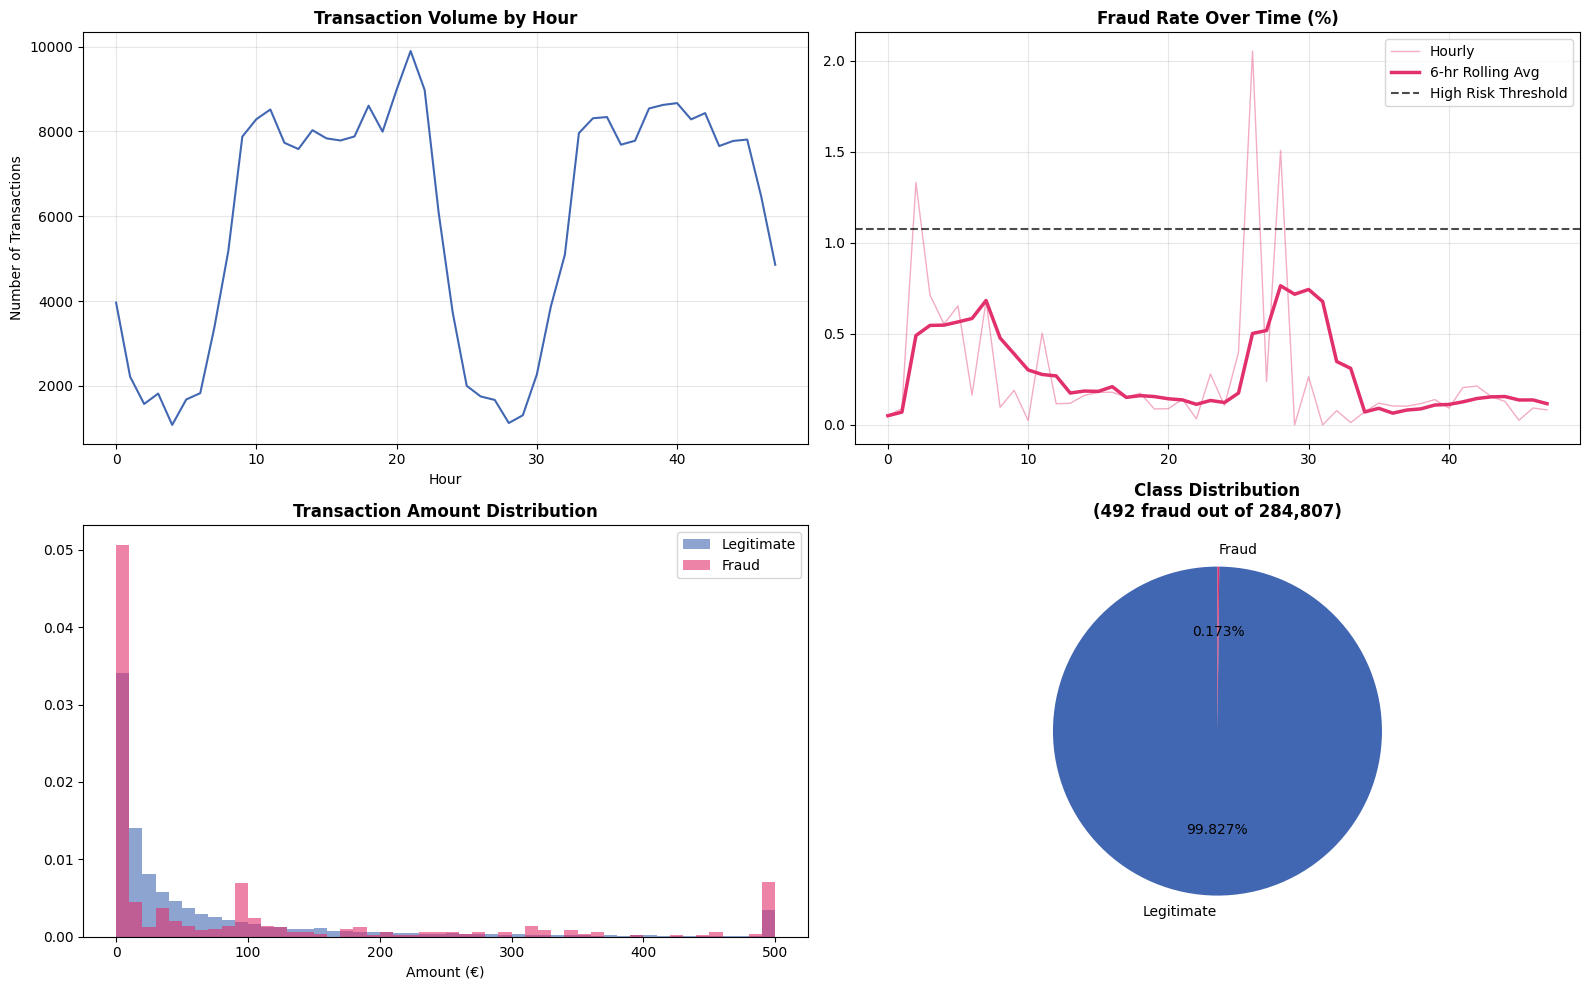

✅ Chart saved to reports/


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Transaction volume over time
axes[0,0].plot(rolling_stats['hour'], rolling_stats['total_transactions'],
               color='#4267B2', linewidth=1.5)
axes[0,0].set_title('Transaction Volume by Hour', fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Number of Transactions')
axes[0,0].grid(alpha=0.3)

# 2. Fraud rate over time with rolling average
axes[0,1].plot(rolling_stats['hour'], rolling_stats['fraud_rate'] * 100,
               color='#E1306C', alpha=0.4, linewidth=1, label='Hourly')
axes[0,1].plot(rolling_stats['hour'], rolling_stats['rolling_6hr_fraud_rate'] * 100,
               color='#E1306C', linewidth=2.5, label='6-hr Rolling Avg')
axes[0,1].axhline(y=(mean_fraud + 2*std_fraud)*100, color='black',
                   linestyle='--', alpha=0.7, label='High Risk Threshold')
axes[0,1].set_title('Fraud Rate Over Time (%)', fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Amount distribution
axes[1,0].hist(df[df.Class==0]['Amount'].clip(upper=500),
               bins=50, alpha=0.6, color='#4267B2', label='Legitimate', density=True)
axes[1,0].hist(df[df.Class==1]['Amount'].clip(upper=500),
               bins=50, alpha=0.6, color='#E1306C', label='Fraud', density=True)
axes[1,0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[1,0].legend()
axes[1,0].set_xlabel('Amount (€)')

# 4. Class imbalance
class_counts = df['Class'].value_counts()
axes[1,1].pie([class_counts[0], class_counts[1]],
              labels=['Legitimate', 'Fraud'],
              colors=['#4267B2', '#E1306C'],
              autopct='%1.3f%%', startangle=90)
axes[1,1].set_title(f'Class Distribution\n({class_counts[1]} fraud out of {len(df):,})',
                     fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to reports/")